# EFT Modelling of the 21-cm Signal at z = 9

This notebook demonstrates:
1. Generating a simulated 21-cm brightness temperature field at z = 9 via EFT-based LPT.
2. Modelling the 21-cm power spectrum with **`EFTmodel`** (Qin et al. 2022, [arXiv:2205.06270](https://arxiv.org/abs/2205.06270)):
   - Lagrangian bias operator fields on the grid.
   - 1-loop matter power spectrum P_1loop(k).
   - Tracer P(k) with 5-operator bias basis.
   - Bias parameter fitting to the simulated P(k).
   - On-grid tracer field construction.
   - Redshift-space multipoles P₀, P₂, P₄.
3. **`HEFTmodel`** placeholder (Baradaran et al. 2024, [arXiv:2406.13079](https://arxiv.org/abs/2406.13079)) — *to be implemented, see [issue #6](https://github.com/sambit-giri/toolscosmo/issues/6)*.

---

## 1. Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import toolscosmo as tcm
import tools21cm as t2c

## 2. Cosmological parameters

Cosmological parameters:
  h0     = 0.673
  Om     = 0.315
  Ob     = 0.049
  sigma8 = 0.83
  ns     = 0.963
Using CAMB to estimate linear power spectrum.
sigma_8=0.811
CAMB runtime: 0.19 s


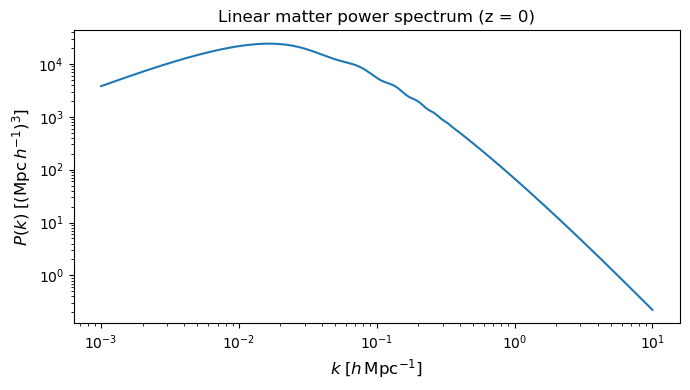

In [2]:
param = tcm.par()
print('Cosmological parameters:')
print(f'  h0     = {param.cosmo.h0}')
print(f'  Om     = {param.cosmo.Om}')
print(f'  Ob     = {param.cosmo.Ob}')
print(f'  sigma8 = {param.cosmo.s8}')
print(f'  ns     = {param.cosmo.ns}')

plin = tcm.get_Plin(param)
param.file.ps = plin

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(plin['k'], plin['P'])
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}\,h^{-1})^3]$', fontsize=12)
ax.set_title('Linear matter power spectrum (z = 0)')
plt.tight_layout()
plt.show()

## 3. Simulation setup

In [3]:
z         = 9.0    # target redshift
grid_size = 64     # grid cells per side  (use 128+ for publication quality)
box_size  = 200.0  # comoving box length  [Mpc/h]

Dz = float(tcm.growth_factor(np.array([z]), param)[0])
fz = float(tcm.growth_rate(np.array([z]), param)[0])

print(f'Redshift z          = {z}')
print(f'Growth factor D(z)  = {Dz:.5f}')
print(f'Growth rate   f(z)  = {fz:.5f}')
print(f'Grid                = {grid_size}³')
print(f'Box                 = {box_size} Mpc/h')
print(f'k_fundamental       = {2*np.pi/box_size:.4f} h/Mpc')
print(f'k_Nyquist           = {np.pi*grid_size/box_size:.4f} h/Mpc')

Redshift z          = 9.0
Growth factor D(z)  = 0.12699
Growth rate   f(z)  = 0.99787
Grid                = 64³
Box                 = 200.0 Mpc/h
k_fundamental       = 0.0314 h/Mpc
k_Nyquist           = 1.0053 h/Mpc


## 4. Generate the linear density field at z = 9

1LPT (Zel'dovich) with no EFT counterterms gives a density field equivalent to the
linear field at z = 0.  Multiplying by D(z = 9) scales it to the target redshift.

In [4]:
delta_lpt_z0 = tcm.compute_EPT_delta(
    param, grid_size, box_size,
    order=1, cs=0.0, MAS='CIC',
    random_seed=42, verbose=True,
)

delta_lin = delta_lpt_z0 * Dz

print(f'\nLinear density field at z = {z:.0f}:')
print(f'  mean = {delta_lin.mean():.4e}')
print(f'  std  = {delta_lin.std():.4f}')

Generating Gaussian random field...
Generating Gaussian random field...
...done in 0.015 seconds
Computing LPT displacements...
Computing total displacement...
Computing density field...
Using CIC (backend=auto) mass assignment scheme
Time taken = 0.495 seconds

Linear density field at z = 9:
  mean = -9.3264e-12
  std  = 0.0503


## 5. Generate the simulated 21-cm field

Use `compute_21cm_EFT_tracer` with fiducial bias parameters to produce a
brightness-temperature contrast field at z = 9.  This serves as our
"observed" field that EFTmodel will later be fitted to.

In [5]:
b1_fid, b2_fid, bs_fid = 1.5, 0.3, 0.1  # fiducial bias

delta_21cm = tcm.compute_21cm_EFT_tracer(
    param, grid_size, box_size, z,
    b1=b1_fid, b2=b2_fid, bs=bs_fid,
    order_lpt=1, cs=0.0, MAS='CIC',
    beta=fz / b1_fid, sigma_v=2.0,
    random_seed=42, verbose=True,
)

print(f'\n21-cm field at z = {z:.0f}:')
print(f'  mean = {delta_21cm.mean():.4e}')
print(f'  std  = {delta_21cm.std():.4f}')

Generating Gaussian random field...
Generating Gaussian random field...
...done in 0.015 seconds
Computing LPT displacements...
Computing total displacement...
Computing density field...
Using CIC (backend=auto) mass assignment scheme
Time taken = 0.002 seconds
Computing bias terms...
Adding RSD...

21-cm field at z = 9:
  mean = 2.3533e-10
  std  = 0.6112


### Visualise the fields

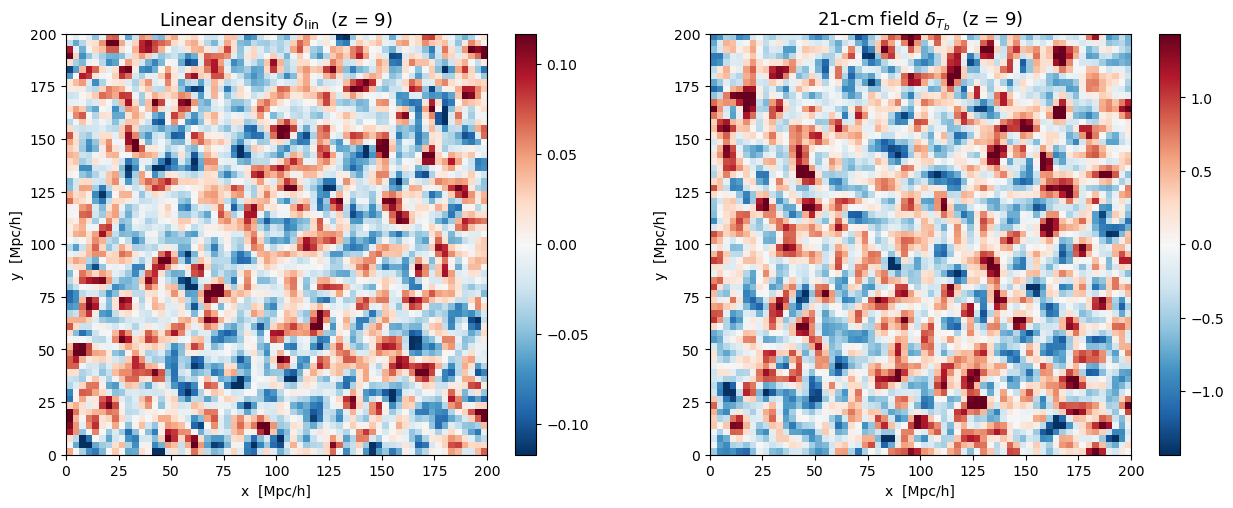

In [6]:
mid = grid_size // 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, field, title in zip(
    axes,
    [delta_lin, delta_21cm],
    [r'Linear density $\delta_{\rm lin}$', r'21-cm field $\delta_{T_b}$'],
):
    vmax = np.percentile(np.abs(field), 98)
    im = ax.imshow(
        field[:, :, mid], origin='lower', cmap='RdBu_r',
        vmin=-vmax, vmax=vmax, extent=[0, box_size, 0, box_size],
    )
    ax.set_title(f'{title}  (z = {z:.0f})', fontsize=13)
    ax.set_xlabel('x  [Mpc/h]')
    ax.set_ylabel('y  [Mpc/h]')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

### Measure power spectra

In [17]:
Pk_sim_lin, k_sim_lin = t2c.power_spectrum_1d(delta_lin,  box_size=box_size)
Pk_sim,     k_sim     = t2c.power_spectrum_1d(delta_21cm, box_size=box_size)

print(f'Measured P_21cm at k ~ 0.1 h/Mpc:  {np.interp(0.1, k_sim, Pk_sim):.2e}  (Mpc/h)^3')

Measured P_21cm at k ~ 0.1 h/Mpc:  5.04e+02  (Mpc/h)^3


---
## 6. EFTmodel

In [18]:
eft = tcm.EFTmodel(
    param,
    grid_size=grid_size,
    box_size=box_size,
    n_q=128, n_mu=64,
    verbose=False,
)
print('EFTmodel initialised.')
print(f'  n_q  = {eft.n_q}')
print(f'  n_mu = {eft.n_mu}')
print(f'  q_UV = {eft.q_UV} h/Mpc')

EFTmodel initialised.
  n_q  = 128
  n_mu = 64
  q_UV = 2.0 h/Mpc


### 6.1  Lagrangian bias operator fields

In [19]:
bias_fields = eft.compute_bias_fields(delta_lin)

print('Bias operator fields:')
for key, val in bias_fields.items():
    print(f'  {key:12s}  mean = {val.mean():.4e},  std = {val.std():.4f}')

Bias operator fields:
  delta         mean = -9.3264e-12,  std = 0.0503
  delta2        mean = 8.4873e-19,  std = 0.0036
  s2            mean = -7.1998e-21,  std = 0.0011
  nabla2delta   mean = 9.3264e-12,  std = 0.0148


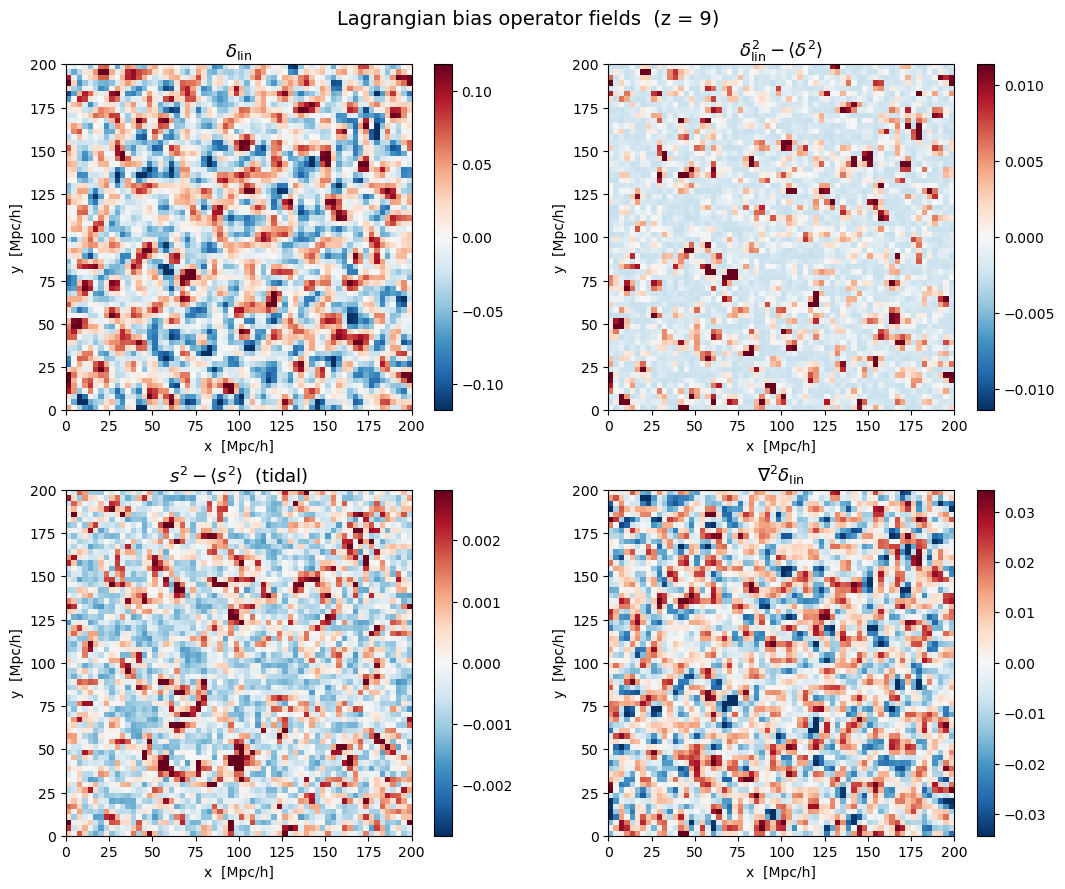

In [20]:
field_labels = {
    'delta':       r'$\delta_{\rm lin}$',
    'delta2':      r'$\delta_{\rm lin}^2 - \langle\delta^2\rangle$',
    's2':          r'$s^2 - \langle s^2\rangle$  (tidal)',
    'nabla2delta': r'$\nabla^2\delta_{\rm lin}$',
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (key, label) in zip(axes.flat, field_labels.items()):
    data = bias_fields[key][:, :, mid]
    vmax = np.percentile(np.abs(data), 98)
    im = ax.imshow(
        data, origin='lower', cmap='RdBu_r',
        vmin=-vmax, vmax=vmax, extent=[0, box_size, 0, box_size],
    )
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('x  [Mpc/h]')
    ax.set_ylabel('y  [Mpc/h]')
    plt.colorbar(im, ax=ax)

plt.suptitle(f'Lagrangian bias operator fields  (z = {z:.0f})', fontsize=14)
plt.tight_layout()
plt.show()

### 6.2  1-loop matter power spectrum

Computing 1-loop integrals ...
Done.


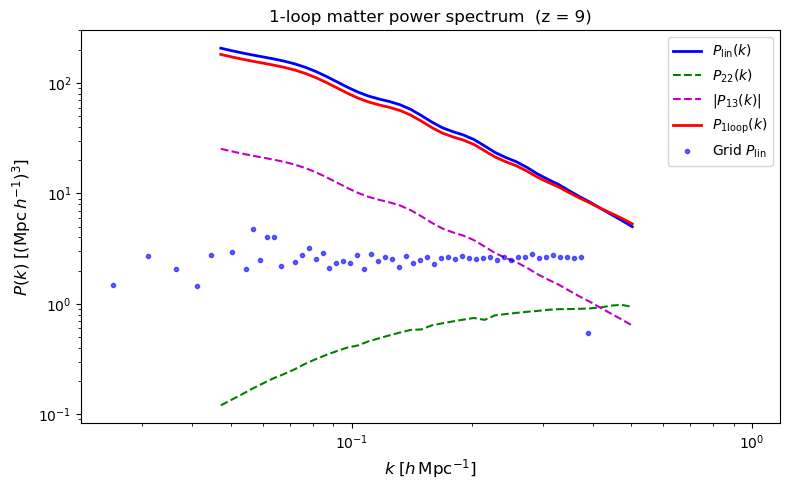

In [21]:
kF  = 2 * np.pi / box_size
kNy = np.pi * grid_size / box_size
k_arr = np.logspace(np.log10(kF * 1.5), np.log10(kNy * 0.5), 40)

print('Computing 1-loop integrals ...')
pk_1loop = eft.P_1loop(k_arr, z)
print('Done.')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(pk_1loop['k'], pk_1loop['P_lin'],  'b-',  lw=2,   label=r'$P_{\rm lin}(k)$')
ax.loglog(pk_1loop['k'], np.abs(pk_1loop['P22']), 'g--', lw=1.5, label=r'$P_{22}(k)$')
ax.loglog(pk_1loop['k'], np.abs(pk_1loop['P13']), 'm--', lw=1.5, label=r'$|P_{13}(k)|$')
ax.loglog(pk_1loop['k'], pk_1loop['P_1loop'], 'r-',  lw=2,   label=r'$P_{\rm 1loop}(k)$')
ax.loglog(k_sim_lin, Pk_sim_lin, 'b.', ms=6, alpha=0.6, label=r'Grid $P_{\rm lin}$')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}\,h^{-1})^3]$', fontsize=12)
ax.set_title(f'1-loop matter power spectrum  (z = {z:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3  Tracer P(k) — fiducial bias

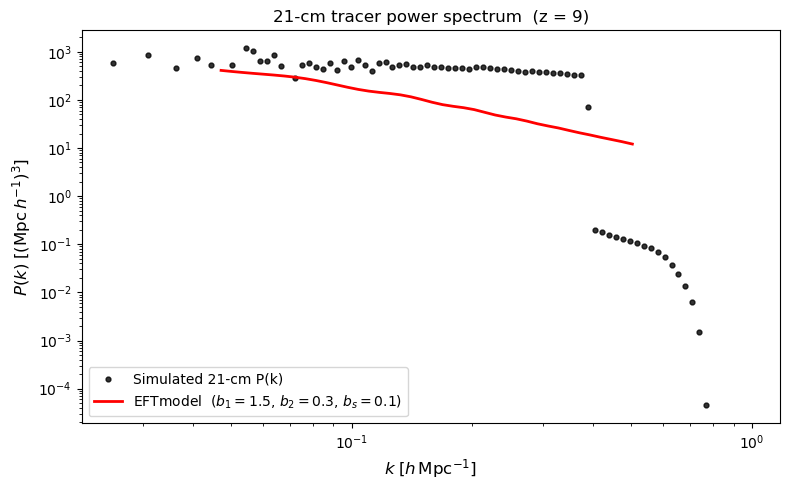

In [22]:
bias_fid = {'b1': b1_fid, 'b2': b2_fid, 'bs': bs_fid, 'bgrad': 0.0, 'be': 0.0}
Pk_tracer_fid = eft.model_P_tracer(k_arr, bias_fid, z)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(k_sim, Pk_sim, 'k.',  ms=7, alpha=0.8, label='Simulated 21-cm P(k)')
ax.loglog(k_arr, Pk_tracer_fid, 'r-', lw=2,
          label=f'EFTmodel  ($b_1={b1_fid}$, $b_2={b2_fid}$, $b_s={bs_fid}$)')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}\,h^{-1})^3]$', fontsize=12)
ax.set_title(f'21-cm tracer power spectrum  (z = {z:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

### 6.4  Bias parameter fitting

In [13]:
k_max_fit = 0.4   # h/Mpc — upper limit of 1-loop validity

mask_fit = (k_sim > kF) & (k_sim < k_max_fit) & (Pk_sim > 0)
k_fit    = k_sim[mask_fit]
Pk_fit   = Pk_sim[mask_fit]

print(f'Fitting on {mask_fit.sum()} k-modes  (k < {k_max_fit} h/Mpc) ...')

fitted_params, opt_result = eft.fit_bias_params(
    k_fit, Pk_fit, z,
    p0={'b1': 1.0, 'b2': 0.0, 'bs': 0.0},
    params_to_fit=('b1', 'b2', 'bs'),
    method='Nelder-Mead',
    options={'xatol': 1e-4, 'fatol': 1e-4, 'maxiter': 2000},
)

print(f'\nFiducial : b1 = {b1_fid:.3f},  b2 = {b2_fid:.3f},  bs = {bs_fid:.3f}')
print(f'Fitted   : b1 = {fitted_params["b1"]:.3f},  b2 = {fitted_params["b2"]:.3f},  bs = {fitted_params["bs"]:.3f}')
print(f'Success  : {opt_result.success}  —  {opt_result.message}')

Fitting on 12 k-modes  (k < 0.4 h/Mpc) ...

Fiducial : b1 = 1.500,  b2 = 0.300,  bs = 0.100
Fitted   : b1 = 0.083,  b2 = 0.001,  bs = 0.001
Success  : True  —  Optimization terminated successfully.


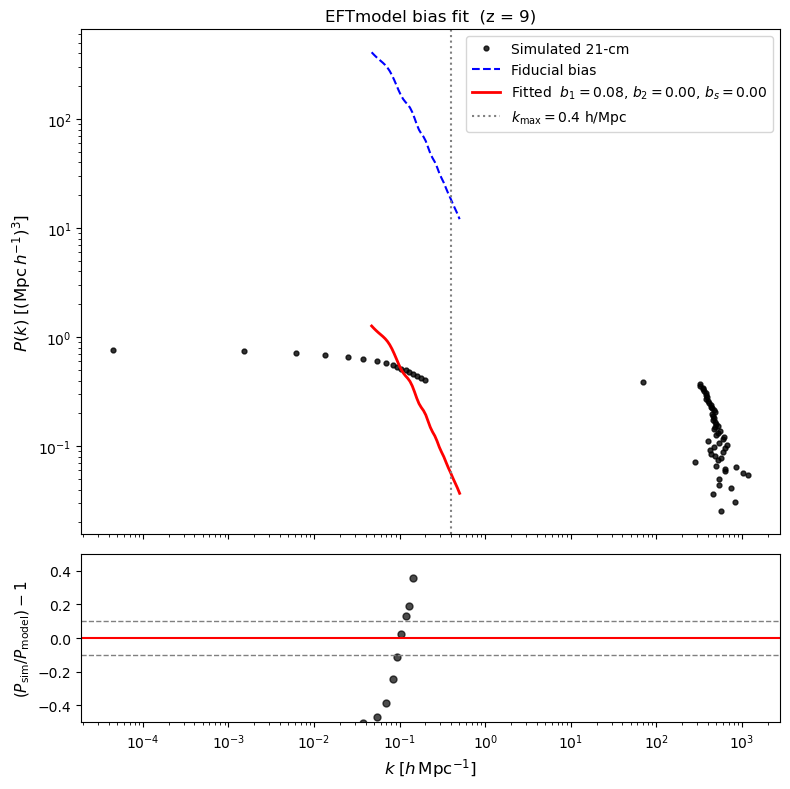

In [14]:
Pk_tracer_fit  = eft.model_P_tracer(k_arr, fitted_params, z)
Pk_fit_at_ksim = np.interp(k_sim[mask_fit], k_arr, Pk_tracer_fit)

fig, axes = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)

axes[0].loglog(k_sim, Pk_sim, 'k.',  ms=7, alpha=0.8, label='Simulated 21-cm')
axes[0].loglog(k_arr, Pk_tracer_fid, 'b--', lw=1.5, label='Fiducial bias')
axes[0].loglog(
    k_arr, Pk_tracer_fit, 'r-', lw=2,
    label=(
        f'Fitted  $b_1={fitted_params["b1"]:.2f}$, '
        f'$b_2={fitted_params["b2"]:.2f}$, '
        f'$b_s={fitted_params["bs"]:.2f}$'
    ),
)
axes[0].axvline(k_max_fit, ls=':', c='gray', label=f'$k_{{\\max}} = {k_max_fit}$ h/Mpc')
axes[0].set_ylabel(r'$P(k)\;[(\mathrm{Mpc}\,h^{-1})^3]$', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_title(f'EFTmodel bias fit  (z = {z:.0f})')

axes[1].semilogx(
    k_sim[mask_fit],
    Pk_sim[mask_fit] / Pk_fit_at_ksim - 1,
    'ko', ms=5, alpha=0.7,
)
for lvl in [0, 0.1, -0.1]:
    axes[1].axhline(lvl, c='r' if lvl == 0 else 'gray',
                    lw=1.5 if lvl == 0 else 1, ls='-' if lvl == 0 else '--')
axes[1].set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
axes[1].set_ylabel(r'$(P_{\rm sim}/P_{\rm model}) - 1$', fontsize=11)
axes[1].set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()

### 6.5  On-grid tracer field

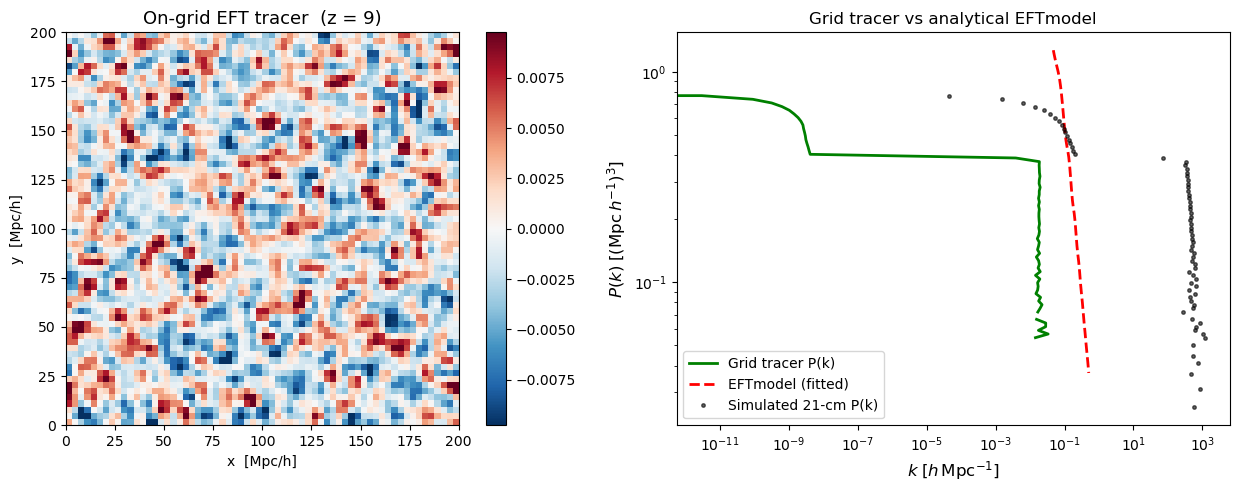

In [15]:
delta_tracer_grid = eft.construct_tracer_field(bias_fields, fitted_params)

k_grid, Pk_grid = t2c.power_spectrum_1d(delta_tracer_grid, box_size=box_size)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vmax_t = np.percentile(np.abs(delta_tracer_grid), 98)
im = axes[0].imshow(
    delta_tracer_grid[:, :, mid], origin='lower', cmap='RdBu_r',
    vmin=-vmax_t, vmax=vmax_t, extent=[0, box_size, 0, box_size],
)
axes[0].set_title(f'On-grid EFT tracer  (z = {z:.0f})', fontsize=13)
axes[0].set_xlabel('x  [Mpc/h]')
axes[0].set_ylabel('y  [Mpc/h]')
plt.colorbar(im, ax=axes[0])

axes[1].loglog(k_grid, Pk_grid,      'g-',  lw=2, label='Grid tracer P(k)')
axes[1].loglog(k_arr, Pk_tracer_fit, 'r--', lw=2, label='EFTmodel (fitted)')
axes[1].loglog(k_sim, Pk_sim,        'k.',  ms=5, alpha=0.6, label='Simulated 21-cm P(k)')
axes[1].set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
axes[1].set_ylabel(r'$P(k)\;[(\mathrm{Mpc}\,h^{-1})^3]$', fontsize=12)
axes[1].set_title('Grid tracer vs analytical EFTmodel')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.6  Redshift-space multipoles

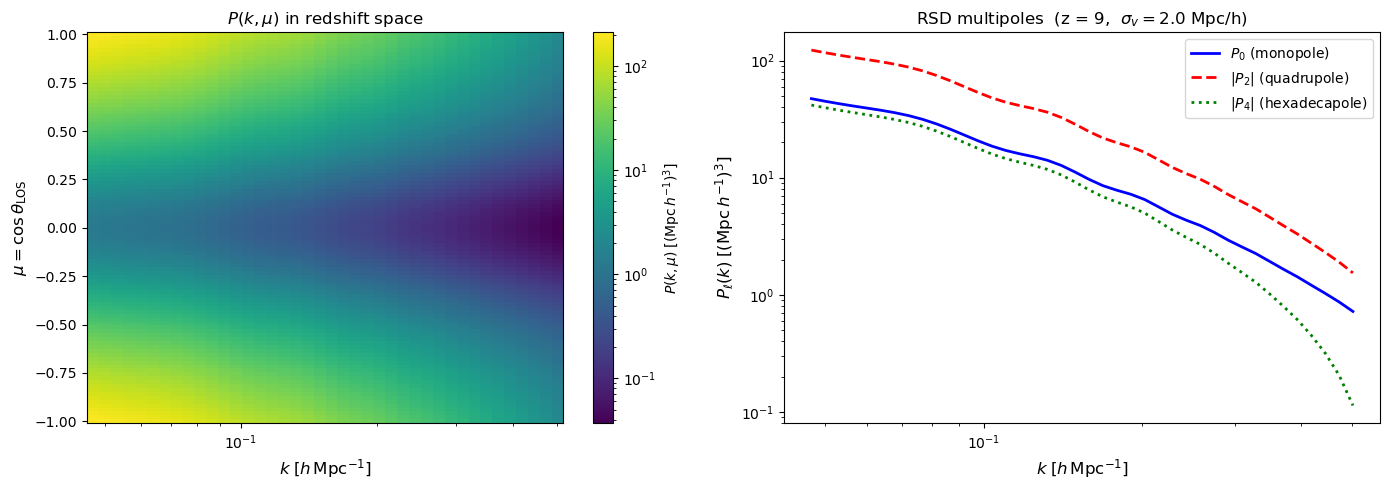

In [16]:
mu_arr = np.linspace(-1, 1, 100)

rsd = eft.model_P_tracer_rsd(
    k_arr, mu_arr, fitted_params, z, fog_sigma=2.0,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].pcolormesh(
    k_arr, mu_arr, rsd['Pk_mu'].T,
    norm=plt.matplotlib.colors.LogNorm(), cmap='viridis',
)
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
axes[0].set_ylabel(r'$\mu = \cos\theta_{\rm LOS}$', fontsize=12)
axes[0].set_title(r'$P(k,\mu)$ in redshift space')
plt.colorbar(im, ax=axes[0], label=r'$P(k,\mu)\;[(\mathrm{Mpc}\,h^{-1})^3]$')

axes[1].loglog(rsd['k'], rsd['P0'],         'b-',  lw=2, label=r'$P_0$ (monopole)')
axes[1].loglog(rsd['k'], np.abs(rsd['P2']), 'r--', lw=2, label=r'$|P_2|$ (quadrupole)')
axes[1].loglog(rsd['k'], np.abs(rsd['P4']), 'g:',  lw=2, label=r'$|P_4|$ (hexadecapole)')
axes[1].set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
axes[1].set_ylabel(r'$P_\ell(k)\;[(\mathrm{Mpc}\,h^{-1})^3]$', fontsize=12)
axes[1].set_title(f'RSD multipoles  (z = {z:.0f},  $\\sigma_v = 2.0$ Mpc/h)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7. HEFTmodel — Hybrid EFT (placeholder)

**`HEFTmodel`** implements the Hybrid EFT formalism from Baradaran et al. 2024
([arXiv:2406.13079](https://arxiv.org/abs/2406.13079)).  
It is currently being developed as part of
[issue #6](https://github.com/sambit-giri/toolscosmo/issues/6).

**Planned workflow:**
1. Compute 5 Lagrangian operators {1, δₗ, δₗ², sₗ², ∇²δₗ} at z_ini on Lagrangian mesh.
2. Advect operators to z = 9 via particle advection with TSC interpolation.
3. Construct 21-cm field as a linear combination of the advected operators.
4. Apply FoG velocity filter (tanh kernel, k₀ = 0.7 h/Mpc, Δk = 0.1 h/Mpc).
5. Compute P(k) from FFT of the reconstructed field.

Once implemented, the comparison will look like:

```python
# heft = tcm.HEFTmodel(param, grid_size=grid_size, box_size=box_size)
# lagrange_ops = heft.compute_lagrangian_operators(delta_lin, z_ini=49.0)
# advected_ops = heft.advect_operators(lagrange_ops, displacement, z_target=z)
# delta_heft   = heft.compute_bias_fields(delta_lin, z)
# fog_field    = heft.apply_fog_filter(velocity_field)
# Pk_heft      = heft.model_P_tracer(k_arr, fitted_params, z)
```